# 05 -> Graph Neural Network Models
## GCN, GraphSAGE, GAT, DOMINANT on Fraud Graphs

> **Colab tip:** Enable GPU: Runtime -> Change runtime type -> T4 GPU

| Model | Architecture | Reference |
|-------|-------------|-----------|
| **GCN** | $H^{(l+1)}=\sigma(\hat{A}H^{(l)}W^{(l)})$ | Kipf & Welling, 2017 |
| **GraphSAGE** | Mean/Max neighborhood sampling | Hamilton et al., 2017 |
| **GAT** | Attention-weighted aggregation | Velickovic et al., 2018 |
| **DOMINANT** | Attribute + structure autoencoder | Ding et al., 2019 |

All models input: **centrality features** (computed in Notebook 03) + graph structure.


In [1]:
# ============================================================
# Google Colab Setup -- Run this cell FIRST every session
# ============================================================
import os, sys, glob

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Roots ────────────────────────────────────────────────────
DRIVE_ROOT   = "/content/drive/MyDrive/fraudDataset"
PROJECT_ROOT = f"{DRIVE_ROOT}/Fraud-Detection-GT"

# Add project src/ to Python path so we can import from src/
sys.path.insert(0, PROJECT_ROOT)

# ── Dataset Paths ─────────────────────────────────────────────
CC_PATH  = f"{DRIVE_ROOT}/creditcard/creditcard.csv"
LEIE_PATH = f"{DRIVE_ROOT}/leie/UPDATED.csv"

# Medicare: 3 separate yearly files (auto-detect names)
MED_DIR = f"{DRIVE_ROOT}/medicare"
MED_FILES = sorted(glob.glob(f"{MED_DIR}/*.csv"))  # finds all CSVs

# ── Output Paths (on Drive  →  survive session restarts) ─────
OUTPUTS_DIR = f"{PROJECT_ROOT}/outputs"
FIGURES_DIR = f"{PROJECT_ROOT}/outputs/figures"
METRICS_DIR = f"{PROJECT_ROOT}/outputs/metrics"
MODELS_DIR  = f"{PROJECT_ROOT}/outputs/models"
GRAPHS_DIR  = f"{PROJECT_ROOT}/data/graphs"

# ML baseline pickles (optional -- upload Fraud-Detection project too)
ML_PICKLES_DIR = f"{DRIVE_ROOT}/Fraud-Detection/pickled_storage"

# Create output directories (idempotent)
for _d in [OUTPUTS_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR, GRAPHS_DIR,
           f"{GRAPHS_DIR}/credit_card", f"{GRAPHS_DIR}/medicare"]:
    os.makedirs(_d, exist_ok=True)

# Load config.yaml
import yaml
_cfg_path = f"{PROJECT_ROOT}/config.yaml"
CONFIG = {}
if os.path.exists(_cfg_path):
    with open(_cfg_path) as _f:
        CONFIG = yaml.safe_load(_f)

# ── Status Report ─────────────────────────────────────────────
print("=" * 58)
print("  Fraud Detection GT  |  Colab + Drive Environment")
print("=" * 58)
print(f"  Project Root  : {PROJECT_ROOT}")
print(f"  Credit Card   : {CC_PATH}")
print(f"  LEIE file     : {LEIE_PATH}")
print(f"  Medicare files: {len(MED_FILES)} found in {MED_DIR}")
for _f in MED_FILES:
    print(f"    - {os.path.basename(_f)}")
print()
print(f"  Outputs       : {OUTPUTS_DIR}")
print()

# Verify
_ok = True
for _path, _label in [(CC_PATH, "creditcard/creditcard.csv"),
                       (LEIE_PATH, "leie/UPDATED.csv")]:
    if os.path.exists(_path):
        _mb = os.path.getsize(_path)/1e6
        print(f"  [OK]  {_label} ({_mb:.0f} MB)")
    else:
        print(f"  [!!]  {_label} NOT FOUND")
        _ok = False

if len(MED_FILES) == 0:
    print("  [!!]  No Medicare CSVs found in medicare/")
    _ok = False
elif len(MED_FILES) < 3:
    print(f"  [??]  Only {len(MED_FILES)} Medicare file(s) found (expected 3)")
else:
    total_mb = sum(os.path.getsize(f)/1e6 for f in MED_FILES)
    print(f"  [OK]  medicare/ ({len(MED_FILES)} files, {total_mb:.0f} MB total)")

print()
print("  Ready!" if _ok else "  WARNING: Some files missing -- check Drive paths above")
print("=" * 58)


Mounted at /content/drive
  Fraud Detection GT  |  Colab + Drive Environment
  Project Root  : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT
  Credit Card   : /content/drive/MyDrive/fraudDataset/creditcard/creditcard.csv
  LEIE file     : /content/drive/MyDrive/fraudDataset/leie/UPDATED.csv
  Medicare files: 3 found in /content/drive/MyDrive/fraudDataset/medicare
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2017.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv

  Outputs       : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs

  [OK]  creditcard/creditcard.csv (151 MB)
  [OK]  leie/UPDATED.csv (15 MB)
  [OK]  medicare/ (3 files, 11921 MB total)

  Ready!


In [2]:
# Install PyTorch Geometric (Colab already has PyTorch)
import subprocess, sys
print("Installing PyTorch Geometric...")
subprocess.check_call([sys.executable,"-m","pip","install","-q","torch-geometric"])
subprocess.check_call([sys.executable,"-m","pip","install","-q","networkx","pyyaml","pyvis"])
print("âœ… Packages installed")


Installing PyTorch Geometric...
âœ… Packages installed


In [3]:
import torch, numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt, matplotlib, time, json
import warnings; warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.facecolor':'#0F0F1A','axes.facecolor':'#1A1A2E',
    'text.color':'#EEEEFF','axes.labelcolor':'#CCCCEE',
    'xtick.color':'#CCCCEE','ytick.color':'#CCCCEE',
})

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch: {torch.__version__}")
print(f"   Device:  {device}")
if device == 'cuda':
    print(f"   GPU:     {torch.cuda.get_device_name(0)}")

import torch_geometric
print(f"PyG: {torch_geometric.__version__}")

from src.graph_builder import load_graph
from src.gnn_models import GCN, GraphSAGE, GAT, DOMINANT, GNNTrainer, prepate_pyg_data
from src.evaluation import compute_metrics


PyTorch: 2.9.0+cpu
   Device:  cpu
PyG: 2.7.0


In [4]:
# Load graphs from Drive
G_cc  = load_graph(f'{GRAPHS_DIR}/credit_card/G_cc_knn.pkl')
G_med = load_graph(f'{GRAPHS_DIR}/medicare/G_med_provider.pkl')
print(f"Graphs loaded")

# Load centrality features (cached in Notebook 03)
try:
    df_cc_cent  = pd.read_csv(f'{METRICS_DIR}/cc_centrality_features.csv')
    df_med_cent = pd.read_csv(f'{METRICS_DIR}/med_centrality_features.csv')
    print(f"Centrality features loaded")
except FileNotFoundError:
    print("Centrality features not found run Notebook 03 first!")
    print("  Computing now (may take 10+ min)...")
    from src.graph_features import compute_centrality_features
    df_cc_cent  = compute_centrality_features(G_cc,  verbose=True)
    df_med_cent = compute_centrality_features(G_med, verbose=True)
    df_cc_cent.to_csv(f'{METRICS_DIR}/cc_centrality_features.csv', index=False)
    df_med_cent.to_csv(f'{METRICS_DIR}/med_centrality_features.csv', index=False)

print(f"CC  features: {df_cc_cent.shape}")
print(f"Med features: {df_med_cent.shape}")


Graphs loaded
Centrality features loaded
CC  features: (50000, 9)
Med features: (7701, 9)


---
## 1. Prepare PyTorch Geometric Data Objects

In [5]:
data_cc  = prepate_pyg_data(G_cc,  df_cc_cent,  seed=42, train_ratio=0.70, val_ratio=0.10)
data_med = prepate_pyg_data(G_med, df_med_cent, seed=42, train_ratio=0.70, val_ratio=0.10)
print(f"\nCC  Data: {data_cc}")
print(f"Med Data: {data_med}")


[PyG Data] Nodes: 50000, Edges: 347127, Features: 7, Fraud: 492
  Train: 34999, Val: 4999, Test: 10002
[PyG Data] Nodes: 7701, Edges: 113350, Features: 7, Fraud: 137
  Train: 5389, Val: 769, Test: 1543

CC  Data: Data(x=[50000, 7], edge_index=[2, 694254], y=[50000], train_mask=[50000], val_mask=[50000], test_mask=[50000])
Med Data: Data(x=[7701, 7], edge_index=[2, 226700], y=[7701], train_mask=[7701], val_mask=[7701], test_mask=[7701])


In [6]:
gnn_results = []

def train_and_eval(model, data, model_name, dataset_name, epochs=200, lr=0.01):
    trainer = GNNTrainer(model, {}, device=device)
    print(f"\n{'='*50}")
    print(f"Training {model_name} on {dataset_name}...")
    t0 = time.time()
    history = trainer.fit(data, epochs=epochs, lr=lr, verbose=True)
    train_time = time.time()-t0

    test_m = trainer.evaluate(data, 'test_mask')
    print(f"\n {model_name} | {dataset_name} | TEST RESULTS:")
    print(f"   AUC-ROC : {test_m['auc_roc']:.4f}")
    print(f"   AUC-PRC : {test_m['auc_prc']:.4f}")
    print(f"   F1      : {test_m['f1']:.4f}")
    print(f"   Time    : {train_time:.1f}s")

    # Save model to Drive
    save_p = f'{MODELS_DIR}/{model_name}_{dataset_name.replace(" ","_").lower()}.pt'
    torch.save(model.state_dict(), save_p)
    print(f"   Saved   : {save_p}")

    gnn_results.append({
        'dataset': dataset_name, 'category': 'Graph-GNN',
        'method': model_name,
        'auc_roc': test_m['auc_roc'], 'auc_prc': test_m['auc_prc'],
        'f1': test_m['f1'], 'train_time': train_time,
    })
    return history


---
## 2. GCN - Graph Convolutional Network
```
GCNConv(in -> 64) -> ReLU -> Dropout(0.5)
GCNConv(64 -> 32) -> ReLU -> Dropout(0.5)
Linear(32 -> 1)   -> Sigmoid -> fraud probability
```


In [7]:
in_cc  = data_cc.x.shape[1]
in_med = data_med.x.shape[1]

# Credit Card
gcn_cc = GCN(in_cc, hidden_channels=64, dropout=0.5)
print(gcn_cc)
hist_gcn_cc = train_and_eval(gcn_cc, data_cc, 'GCN', 'Credit Card', epochs=200, lr=0.01)


GCN(
  (conv1): GCNConv(7, 64)
  (conv2): GCNConv(64, 32)
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Training GCN on Credit Card...
  Epoch 020 | Loss: 0.0864 | Val AUC: 0.5573 | Val AP: 0.0133
  Epoch 040 | Loss: 0.0738 | Val AUC: 0.5714 | Val AP: 0.0182
  Epoch 060 | Loss: 0.0678 | Val AUC: 0.5781 | Val AP: 0.0249
  Epoch 080 | Loss: 0.0660 | Val AUC: 0.5812 | Val AP: 0.0281
  Epoch 100 | Loss: 0.0655 | Val AUC: 0.5852 | Val AP: 0.0304
  Epoch 120 | Loss: 0.0645 | Val AUC: 0.5891 | Val AP: 0.0326
  Epoch 140 | Loss: 0.0639 | Val AUC: 0.5957 | Val AP: 0.0414
  Epoch 160 | Loss: 0.0647 | Val AUC: 0.6117 | Val AP: 0.0633
  Epoch 180 | Loss: 0.0637 | Val AUC: 0.6524 | Val AP: 0.1003
  Epoch 200 | Loss: 0.0613 | Val AUC: 0.7434 | Val AP: 0.1248

 GCN | Credit Card | TEST RESULTS:
   AUC-ROC : 0.6144
   AUC-PRC : 0.0693
   F1      : 0.1204
   Time    : 35.2s
   Saved   : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs/models/GCN_credit_card.pt


In [8]:
# Medicare
gcn_med = GCN(in_med, hidden_channels=64, dropout=0.5)
hist_gcn_med = train_and_eval(gcn_med, data_med, 'GCN', 'Medicare', epochs=200, lr=0.01)



Training GCN on Medicare...
  Epoch 020 | Loss: 0.3674 | Val AUC: 0.5126 | Val AP: 0.0172
  Epoch 040 | Loss: 0.1527 | Val AUC: 0.5689 | Val AP: 0.0247
  Epoch 060 | Loss: 0.1579 | Val AUC: 0.5716 | Val AP: 0.0240
  Epoch 080 | Loss: 0.1415 | Val AUC: 0.5849 | Val AP: 0.0239
  Epoch 100 | Loss: 0.1503 | Val AUC: 0.5766 | Val AP: 0.0240
  Epoch 120 | Loss: 0.1480 | Val AUC: 0.5769 | Val AP: 0.0240
  Epoch 140 | Loss: 0.1246 | Val AUC: 0.5684 | Val AP: 0.0239
  Epoch 160 | Loss: 0.1294 | Val AUC: 0.5679 | Val AP: 0.0238
  Epoch 180 | Loss: 0.1219 | Val AUC: 0.5603 | Val AP: 0.0236
  Epoch 200 | Loss: 0.1295 | Val AUC: 0.5630 | Val AP: 0.0236

 GCN | Medicare | TEST RESULTS:
   AUC-ROC : 0.6139
   AUC-PRC : 0.0273
   F1      : 0.0571
   Time    : 9.7s
   Saved   : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs/models/GCN_medicare.pt


---
## 3. GraphSAGE -> Inductive Representation Learning

In [9]:
sage_cc  = GraphSAGE(in_cc,  hidden_channels=64, aggr='mean', dropout=0.5)
sage_med = GraphSAGE(in_med, hidden_channels=64, aggr='mean', dropout=0.5)

hist_sage_cc  = train_and_eval(sage_cc,  data_cc,  'GraphSAGE', 'Credit Card', epochs=200, lr=0.01)
hist_sage_med = train_and_eval(sage_med, data_med, 'GraphSAGE', 'Medicare',    epochs=200, lr=0.01)



Training GraphSAGE on Credit Card...
  Epoch 020 | Loss: 0.0974 | Val AUC: 0.5423 | Val AP: 0.0367
  Epoch 040 | Loss: 0.0760 | Val AUC: 0.5398 | Val AP: 0.0314
  Epoch 060 | Loss: 0.0722 | Val AUC: 0.5400 | Val AP: 0.0401
  Epoch 080 | Loss: 0.0727 | Val AUC: 0.5323 | Val AP: 0.0546
  Epoch 100 | Loss: 0.0696 | Val AUC: 0.5344 | Val AP: 0.0648
  Epoch 120 | Loss: 0.0693 | Val AUC: 0.5377 | Val AP: 0.0698
  Epoch 140 | Loss: 0.0690 | Val AUC: 0.5536 | Val AP: 0.0830
  Epoch 160 | Loss: 0.0688 | Val AUC: 0.5699 | Val AP: 0.0903
  Epoch 180 | Loss: 0.0661 | Val AUC: 0.5973 | Val AP: 0.1040
  Epoch 200 | Loss: 0.0651 | Val AUC: 0.6403 | Val AP: 0.1378

 GraphSAGE | Credit Card | TEST RESULTS:
   AUC-ROC : 0.5171
   AUC-PRC : 0.0643
   F1      : 0.0960
   Time    : 28.4s
   Saved   : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs/models/GraphSAGE_credit_card.pt

Training GraphSAGE on Medicare...
  Epoch 020 | Loss: 1.4738 | Val AUC: 0.4706 | Val AP: 0.0161
  Epoch 040 | Lo

---
## 4. GAT -> Graph Attention Network

In [10]:
gat_cc  = GAT(in_cc,  hidden_channels=8, heads=4, dropout=0.6)
gat_med = GAT(in_med, hidden_channels=8, heads=4, dropout=0.6)

hist_gat_cc  = train_and_eval(gat_cc,  data_cc,  'GAT', 'Credit Card', epochs=200, lr=0.005)
hist_gat_med = train_and_eval(gat_med, data_med, 'GAT', 'Medicare',    epochs=200, lr=0.005)



Training GAT on Credit Card...
  Epoch 020 | Loss: 0.2501 | Val AUC: 0.4338 | Val AP: 0.0145
  Epoch 040 | Loss: 0.0987 | Val AUC: 0.4344 | Val AP: 0.0115
  Epoch 060 | Loss: 0.0686 | Val AUC: 0.4260 | Val AP: 0.0107
  Epoch 080 | Loss: 0.0726 | Val AUC: 0.4277 | Val AP: 0.0108
  Epoch 100 | Loss: 0.0650 | Val AUC: 0.4323 | Val AP: 0.0110
  Epoch 120 | Loss: 0.0663 | Val AUC: 0.4357 | Val AP: 0.0116
  Epoch 140 | Loss: 0.0648 | Val AUC: 0.4394 | Val AP: 0.0122
  Epoch 160 | Loss: 0.0639 | Val AUC: 0.4426 | Val AP: 0.0129
  Epoch 180 | Loss: 0.0639 | Val AUC: 0.4462 | Val AP: 0.0138
  Epoch 200 | Loss: 0.0651 | Val AUC: 0.4499 | Val AP: 0.0151

 GAT | Credit Card | TEST RESULTS:
   AUC-ROC : 0.3586
   AUC-PRC : 0.0136
   F1      : 0.0196
   Time    : 51.8s
   Saved   : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs/models/GAT_credit_card.pt

Training GAT on Medicare...
  Epoch 020 | Loss: 0.2763 | Val AUC: 0.4952 | Val AP: 0.0166
  Epoch 040 | Loss: 0.1916 | Val AUC: 0.

---
## 5. DOMINANT -> Unsupervised Deep Anomaly Detection

No labels during training. Learns to reconstruct node attributes and graph structure.
Anomaly score: $s(v) = \alpha \cdot err_{struct}(v) + (1-\alpha) \cdot err_{attr}(v)$


In [11]:
def train_dominant(data, dataset_name, epochs=100, lr=0.001, alpha=0.5):
    import torch.nn as nn
    model = DOMINANT(data.x.shape[1], hidden_channels=64,
                     embedding_dim=32, dropout=0.3, alpha=alpha).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    data_d = data.to(device)
    n = data_d.x.shape[0]

    print(f"\nTraining DOMINANT on {dataset_name} ({epochs} epochs)...")
    t0 = time.time()
    for epoch in range(1, epochs+1):
        model.train(); optimizer.zero_grad()
        x_hat, adj_hat, z = model(data_d.x, data_d.edge_index)
        adj_dense = torch.zeros(n, n, device=device)
        adj_dense[data_d.edge_index[0], data_d.edge_index[1]] = 1.0
        attr_loss   = ((data_d.x - x_hat)**2).mean()
        struct_loss = ((adj_dense - adj_hat)**2).mean()
        loss = alpha*struct_loss + (1-alpha)*attr_loss
        loss.backward(); optimizer.step()
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:03d} | Loss:{loss.item():.4f} "
                  f"Attr:{attr_loss.item():.4f} Struct:{struct_loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        x_hat, adj_hat, z = model(data_d.x, data_d.edge_index)
        adj_dense = torch.zeros(n, n, device=device)
        adj_dense[data_d.edge_index[0], data_d.edge_index[1]] = 1.0
        scores = model.compute_anomaly_scores(data_d.x, x_hat, adj_hat, adj_dense).cpu().numpy()

    labels = data_d.y.cpu().numpy()
    test_mask = data_d.test_mask.cpu().numpy()
    from sklearn.metrics import roc_auc_score, average_precision_score
    if labels[test_mask].sum() > 0:
        auc = roc_auc_score(labels[test_mask], scores[test_mask])
        ap  = average_precision_score(labels[test_mask], scores[test_mask])
        print(f"\n  DOMINANT | {dataset_name} -> AUC:{auc:.4f} | AP:{ap:.4f} ({time.time()-t0:.0f}s)")
    else:
        auc, ap = 0, 0

    gnn_results.append({'dataset': dataset_name, 'category': 'Graph-GNN-Unsup',
                         'method': 'DOMINANT', 'auc_roc': auc, 'auc_prc': ap, 'f1': None,
                         'train_time': time.time()-t0})

train_dominant(data_cc,  'Credit Card', epochs=100)
train_dominant(data_med, 'Medicare',    epochs=100)



Training DOMINANT on Credit Card (100 epochs)...
  Epoch 020 | Loss:1.5132 Attr:2.0267 Struct:0.9997
  Epoch 040 | Loss:0.8890 Attr:0.7783 Struct:0.9997
  Epoch 060 | Loss:0.8021 Attr:0.6045 Struct:0.9997
  Epoch 080 | Loss:0.7860 Attr:0.5723 Struct:0.9997
  Epoch 100 | Loss:0.7791 Attr:0.5585 Struct:0.9997

  DOMINANT | Credit Card -> AUC:0.5708 | AP:0.0197 (1264s)

Training DOMINANT on Medicare (100 epochs)...
  Epoch 020 | Loss:644.3156 Attr:1288.0408 Struct:0.5904
  Epoch 040 | Loss:374.4008 Attr:748.3610 Struct:0.4407
  Epoch 060 | Loss:360.7704 Attr:721.1354 Struct:0.4054
  Epoch 080 | Loss:351.0252 Attr:701.6434 Struct:0.4071
  Epoch 100 | Loss:358.0654 Attr:715.7215 Struct:0.4093

  DOMINANT | Medicare -> AUC:0.5509 | AP:0.0200 (37s)


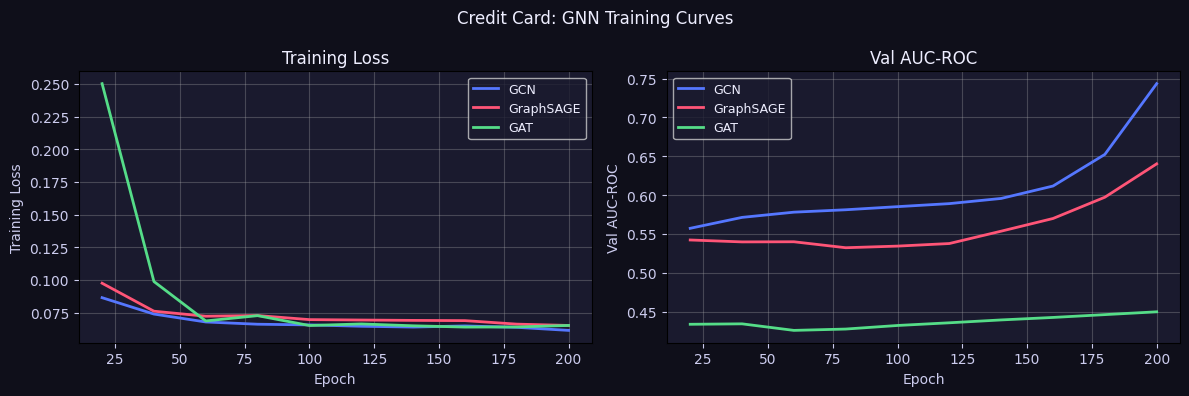

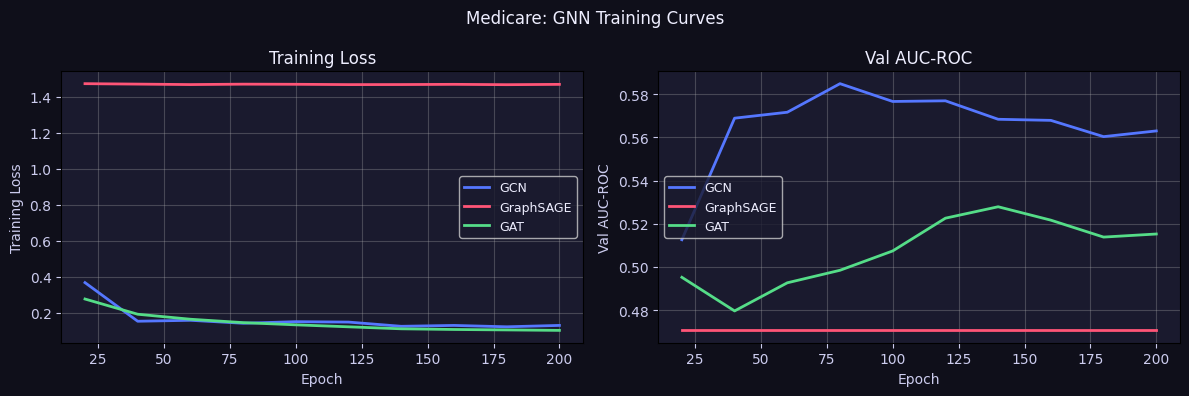

In [12]:
# Training curves
def plot_training_curves(histories, labels, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    fig.suptitle(title, fontsize=12, color='#EEEEFF')
    colors = ['#5577FF','#FF5577','#55DD88','#FFAA33']

    for ax, (metric, ylabel) in zip(axes, [('train_loss','Training Loss'),('auc_roc','Val AUC-ROC')]):
        for hist, lbl, col in zip(histories, labels, colors):
            if not hist: continue
            epochs = [h['epoch'] for h in hist]
            vals   = [h.get(metric, 0) for h in hist]
            ax.plot(epochs, vals, color=col, lw=2, label=lbl)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(ylabel); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves([hist_gcn_cc, hist_sage_cc, hist_gat_cc],
                     ['GCN','GraphSAGE','GAT'],
                     'Credit Card: GNN Training Curves',
                     f'{FIGURES_DIR}/cc_gnn_training.png')

plot_training_curves([hist_gcn_med, hist_sage_med, hist_gat_med],
                     ['GCN','GraphSAGE','GAT'],
                     'Medicare: GNN Training Curves',
                     f'{FIGURES_DIR}/med_gnn_training.png')


In [13]:
with open(f'{METRICS_DIR}/gnn_results.json', 'w') as f:
    json.dump(gnn_results, f, indent=2, default=str)
print("GNN results saved to Drive")

print("\n" + "="*55)
print("  NOTEBOOK 05 COMPLETE")
print("="*55)
for r in gnn_results:
    print(f"  {r['dataset']:<15}|{r['method']:<12}: AUC={r['auc_roc']:.4f} AP={r['auc_prc']:.4f}")
print()
print("  Models + results saved to Drive")
print("  Next 06_Comparison_and_Results.ipynb")
print("="*55)


GNN results saved to Drive

  NOTEBOOK 05 COMPLETE
  Credit Card    |GCN         : AUC=0.6144 AP=0.0693
  Medicare       |GCN         : AUC=0.6139 AP=0.0273
  Credit Card    |GraphSAGE   : AUC=0.5171 AP=0.0643
  Medicare       |GraphSAGE   : AUC=0.4309 AP=0.0171
  Credit Card    |GAT         : AUC=0.3586 AP=0.0136
  Medicare       |GAT         : AUC=0.4361 AP=0.0159
  Credit Card    |DOMINANT    : AUC=0.5708 AP=0.0197
  Medicare       |DOMINANT    : AUC=0.5509 AP=0.0200

  Models + results saved to Drive
  Next 06_Comparison_and_Results.ipynb
